In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


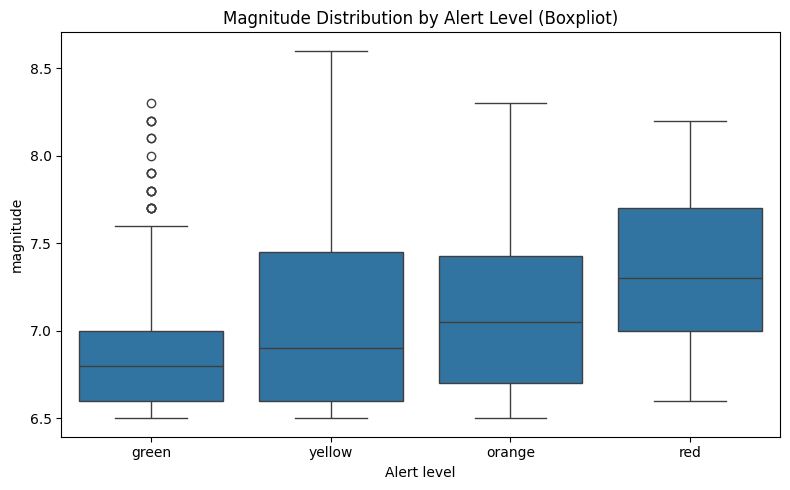

In [ ]:
df = pd.read_csv('/content/earthquake_1995-2023.csv')

# Define alert_order based on unique values in the 'alert' column, excluding 'unknow' and NaN values
alert_order = df['alert'].dropna().unique().tolist()
if 'unknow' in alert_order:
    alert_order.remove('unknow')
# Optional: Sort for consistent plotting if no specific order is intended
# alert_order.sort()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['alert'].notna() & (df['alert'] !='unknow')], x='alert', y='magnitude', order=alert_order) # Changed plt.boxplot to sns.boxplot and added filtering for NaN values
plt.title('Magnitude Distribution by Alert Level (Boxpliot)')
plt.xlabel('Alert level')
plt.ylabel('magnitude')
plt.tight_layout()
plt.show()

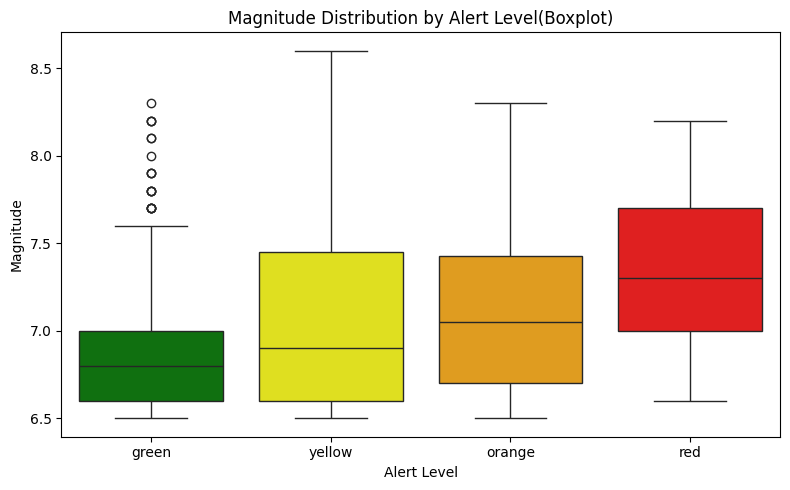

In [ ]:
plt.figure(figsize=(8,5))
alert_colors = {'green': 'green', 'yellow': 'yellow', 'orange': 'orange', 'red': 'red'}

# The current df (from kernel state) has an 'alert' column, not 'alert_level'.
# alert_order in kernel state is ['green', 'yellow', 'orange', 'red'], which is used here.
alert_order = ['green', 'yellow', 'orange', 'red']

# Filter the DataFrame to exclude NaN values in 'alert' and 'unknow' entries
plot_df = df[df['alert'].notna() & (df['alert'] != 'unknow')]

# Use 'alert' column name instead of 'alert_level' for x and hue
sns.boxplot(data=plot_df, x='alert', y='magnitude', order=alert_order, hue='alert', palette=alert_colors)
plt.title('Magnitude Distribution by Alert Level(Boxplot)')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

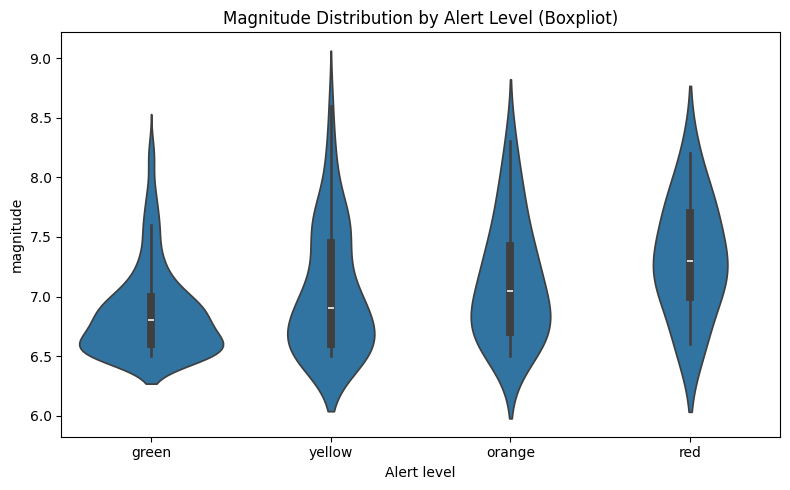

In [ ]:

plt.figure(figsize=(8, 5))
sns.violinplot(data=df[df['alert'].notna() & (df['alert'] !='unknow')], x='alert', y='magnitude', order=alert_order) # Changed plt.boxplot to sns.boxplot and added filtering for NaN values
plt.title('Magnitude Distribution by Alert Level (Boxpliot)')
plt.xlabel('Alert level')
plt.ylabel('magnitude')
plt.tight_layout()
plt.show()

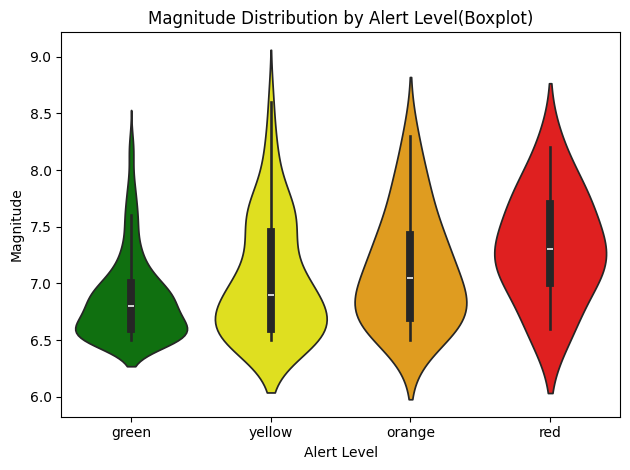

In [ ]:
sns.violinplot(data=plot_df, x='alert', y='magnitude', order=alert_order, hue='alert', palette=alert_colors)
plt.title('Magnitude Distribution by Alert Level(Boxplot)')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

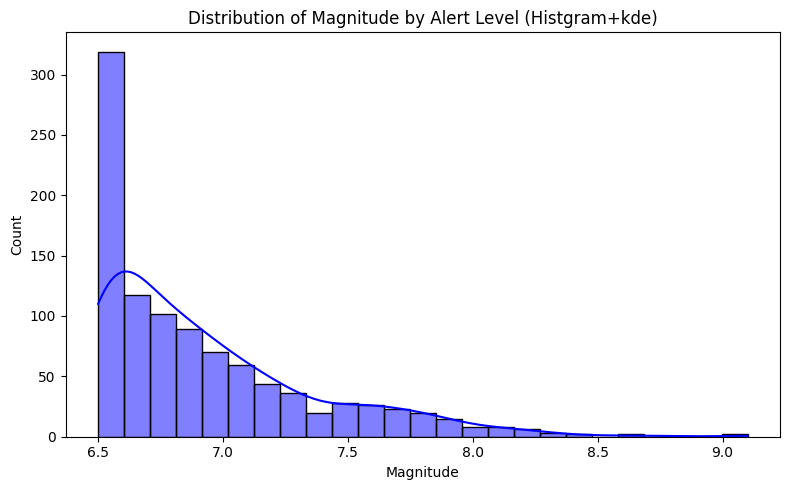

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='magnitude', kde=True,bins=25, color='blue')
plt.title('Distribution of Magnitude by Alert Level (Histgram+kde)')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

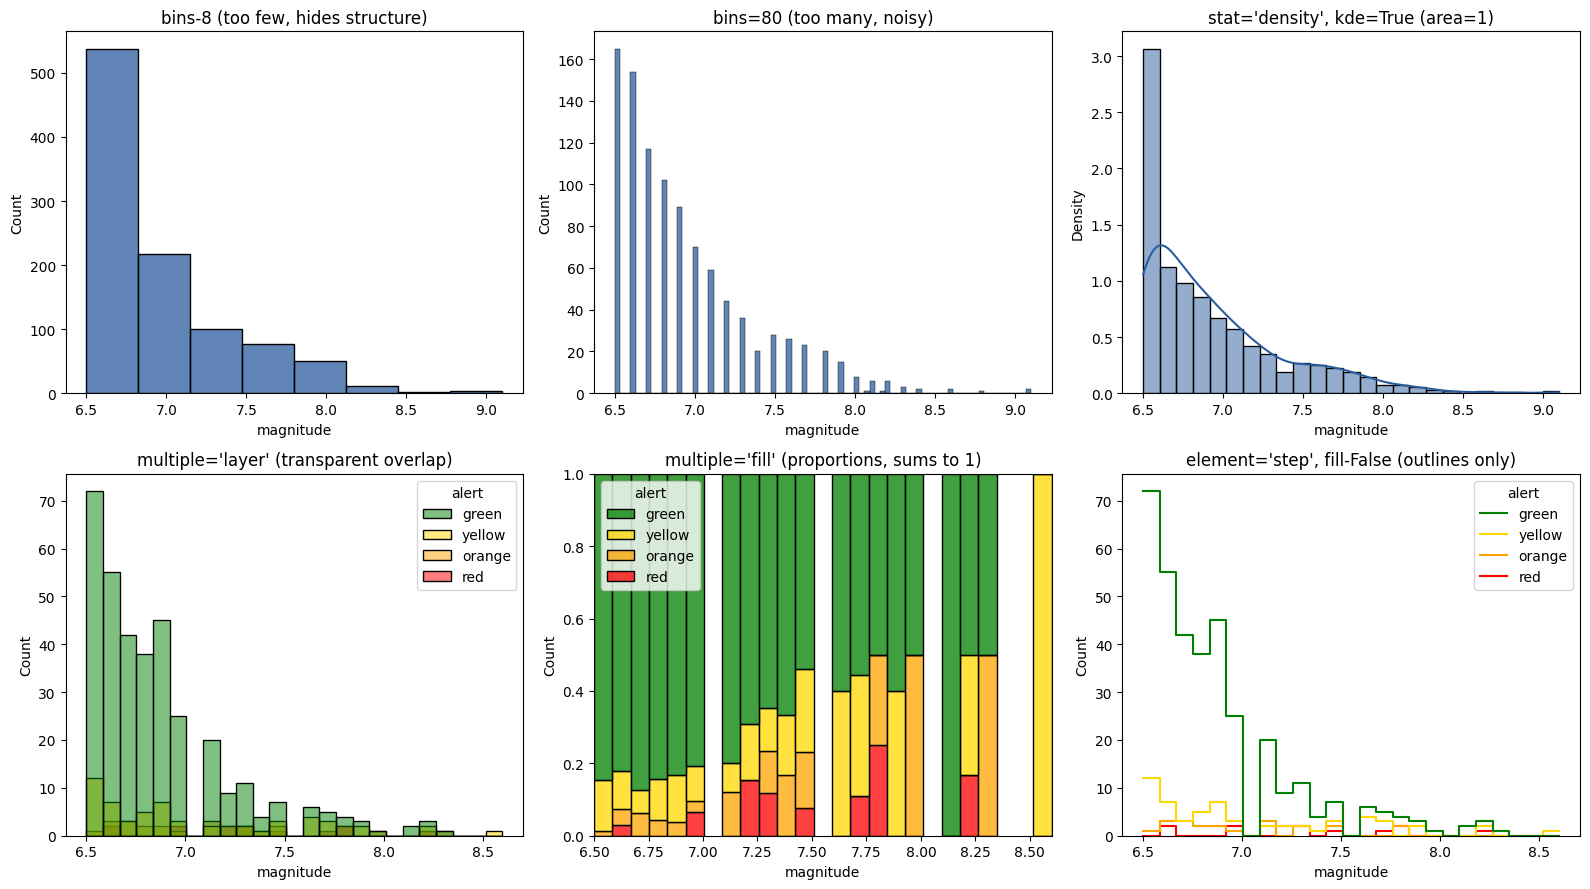

In [ ]:
order = ['green', 'yellow', 'orange', 'red']

pal = ['green', 'gold', 'orange', 'red']

d = df[df['alert'] != 'unknown']

# 2 rows x 3 columns of axes; ax is a 2D array you index as ax[row, col]

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# 1. too few bins

sns.histplot(data=df, x='magnitude', bins=8, color='#2b5c9e', ax=ax[0, 0])
ax[0, 0].set_title("bins-8 (too few, hides structure)")

# 2. too many bins

sns.histplot(data=df, x='magnitude', bins=80, color='#2b5c9e', ax=ax[0, 1])
ax[0, 1].set_title("bins=80 (too many, noisy)")

#3. stat='density' + kde

sns.histplot(data=df, x='magnitude', stat='density', kde=True, bins=25, color='#2b5c9e', ax=ax[0, 2])

ax[0, 2].set_title("stat='density', kde=True (area=1)")

# 4. hue + multiple='layer'

sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, multiple='layer', bins=25, ax=ax[1, 0])

ax[1, 0].set_title("multiple='layer' (transparent overlap)")

# 5. hue + multiple='fill'

sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, multiple='fill', bins=25, ax=ax[1, 1])
ax[1, 1].set_title("multiple='fill' (proportions, sums to 1)")

# 6. element='step', outlines only

sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, element='step', fill=False, bins=25, ax=ax[1, 2])
ax[1, 2].set_title("element='step', fill-False (outlines only)")

plt.tight_layout()
plt.show()

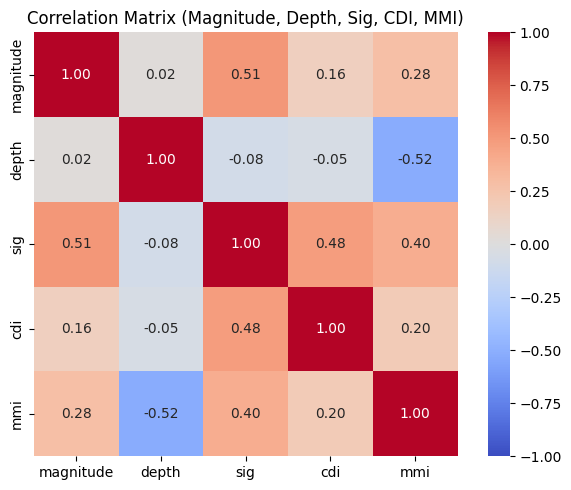

In [ ]:
columns_for_correlation = ['magnitude', 'depth', 'sig', 'cdi', 'mmi']
corr = df[columns_for_correlation].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm',vmin=-1,vmax=1, fmt='.2f', square=True)
plt.title('Correlation Matrix (Magnitude, Depth, Sig, CDI, MMI)')
plt.tight_layout()
plt.show()